In [2]:
import pandas as pd
import json
from datetime import datetime
from pprint import pprint
import matplotlib.pyplot as plt
import numpy as np

### LOAD THE DATA - REVIEW DATA

In [3]:
with open("data/amazon_fashion/AMAZON_FASHION.json", "r") as f:
    lines = f.readlines()
    f.close()

In [4]:
rows = []
for i, line in enumerate(lines):
    review = json.loads(line)
    entry = {
        "userId": review['reviewerID'],
        "productId": review['asin'],
        "timeStamp": review['unixReviewTime'],
        "reviewText": review['unixReviewTime'],
        "rating" : review['overall']
    }
    rows.append(entry)
review_df = pd.DataFrame(rows)

In [5]:
review_df['timeStamp']  = pd.to_datetime(review_df["timeStamp"], unit='s')
review_df.sort_values(by='timeStamp', inplace=True)

In [6]:
review_df.head(4)

,userId,productId,timeStamp,reviewText,rating
452225,A2KAH6H1AZ644N,B000072XQQ,2002-11-11,1036972800,5.0
398844,A1W8Q4CPGUI2Z0,B000073249,2002-11-14,1037232000,2.0
397048,A1DZATB5VPS5LM,B00007325C,2002-11-26,1038268800,5.0
397087,A20AA4JTZHF6GH,B00007CWBQ,2002-12-11,1039564800,4.0


In [7]:
review_df.tail(4)

,userId,productId,timeStamp,reviewText,rating
869203,A1FKS778XITHK6,B01GGEQSWM,2018-10-01,1538352000,3.0
869215,AQTT6V6MSMYC8,B01GGGSD6E,2018-10-01,1538352000,5.0
869662,A2FDKSBXCJJQ26,B01GHPMJYQ,2018-10-01,1538352000,3.0
882981,A2P6021FB6L6T6,B01HHJZNBM,2018-10-01,1538352000,5.0


In [9]:
review_df.to_csv("data/amazon_fashion/review.csv")

### LOAD THE METADATA

In [10]:
with open("data/amazon_fashion/meta_AMAZON_FASHION.json", "r") as f:
    lines = f.readlines()
    f.close()

In [11]:
rows = []
for i, line in enumerate(lines):
    meta = json.loads(line)
    try:
        entry = {
            "productId": meta["asin"],
            "title": meta["title"],
            "brand" : meta["brand"] if "brand" in meta.keys() else "",
            "description" : " ".join(meta["description"]) if "description" in meta.keys() else ""
        }
        rows.append(entry)
    except Exception as e:
        continue
meta_df = pd.DataFrame(rows)

In [12]:
## Drop Duplicates
if meta_df["productId"].duplicated().any():
    print("There are duplicates")
else:
    print("There are no duplicates")

There are duplicates


In [13]:
meta_df.drop_duplicates(subset=['productId'], inplace=True)

In [14]:
if meta_df.shape[0] == len(meta_df['productId'].unique()):
    print("There are no duplicates")
else:
    print("There are still duplicates")

There are no duplicates


In [15]:
meta_df.head(5)

,productId,title,brand,description
0,0764443682,Slime Time Fall Fest [With CDROM and Collector...,Group Publishing (CO),
1,1291691480,XCC Qi promise new spider snake preparing men'...,,
2,1940280001,Magical Things I Really Do Do Too!,Christopher Manos,For the professional or amateur magician. Rou...
3,1940735033,"Ashes to Ashes, Oranges to Oranges",Flickerlamp Publishing,
4,1940967805,Aether & Empire #1 - 2016 First Printing Comic...,,


In [16]:
print(f"There are {len(meta_df["productId"].unique())} unique products")

There are 186189 unique products


In [18]:
meta_df.to_csv("data/amazon_fashion/meta.csv")

### DROP THE REVIEWS WHICH ARE NOT IN THE PRODUCT TABLE

In [19]:
review_df = pd.read_csv("data/amazon_fashion/review.csv", index_col=0)
print(f"There are {len(review_df["productId"].unique())} products in review table")

There are 186189 products in review table


In [20]:
meta_df = pd.read_csv("data/amazon_fashion/meta.csv", index_col=0)
meta_df.head(3)

,productId,title,brand,description
0,0764443682,Slime Time Fall Fest [With CDROM and Collector...,Group Publishing (CO),NaN
1,1291691480,XCC Qi promise new spider snake preparing men'...,NaN,NaN
2,1940280001,Magical Things I Really Do Do Too!,Christopher Manos,For the professional or amateur magician. Rou...


In [21]:
prodId_to_remove = set(review_df["productId"].unique()).difference(set(meta_df["productId"].unique()))

In [22]:
mod_review_df = review_df[~review_df["productId"].isin(prodId_to_remove)]
len(mod_review_df["productId"].unique())

186184

In [24]:
mod_review_df.to_csv("data/amazon_fashion/review.csv")

### BASIC EXPLORATION ON REVIEW DATA
* #### The dataset has review data from 2002 to 2018
* #### 186184 unique products and 749206 unique reviews
* #### Dist. of product ratings - More 5 rated products as compared with rating 1,2 and 3
* #### Most of the users reviewed at most one product
* #### There are total 320 products having less than 10 reviews

In [25]:
review_df = pd.read_csv("data/amazon_fashion/review.csv", index_col=0)

In [26]:
print(f"There are {review_df['productId'].unique().shape[0]} product Ids")
print(f"There are {review_df['userId'].unique().shape[0]} user Ids")


There are 186184 product Ids
There are 749206 user Ids


Text(0, 0.5, 'Counts')

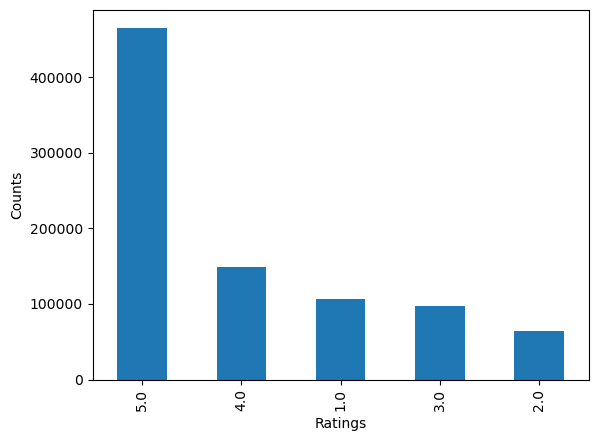

In [27]:
review_df["rating"].value_counts().plot(kind='bar')
plt.xlabel("Ratings")
plt.ylabel("Counts")

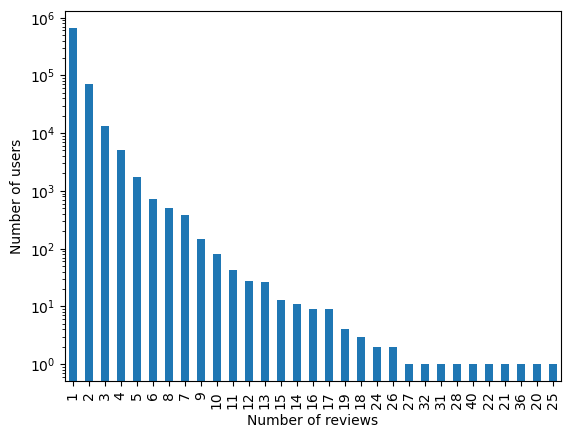

In [23]:
review_df.groupby("userId")["rating"].count().value_counts().plot(kind='bar')
plt.xlabel("Number of reviews")
plt.ylabel("Number of users")
plt.yscale('log')

In [28]:
prod_reviews = review_df.groupby('productId')['rating'].count().value_counts()
low_review_prods = prod_reviews[prod_reviews < 10]
print(f"There are {low_review_prods.shape[0]} products having less than 10 reviews")

There are 320 products having less than 10 reviews


### 

### Checking Sparsity of the Data
* #### The user data is too sparse, most of the users have only 1 rating

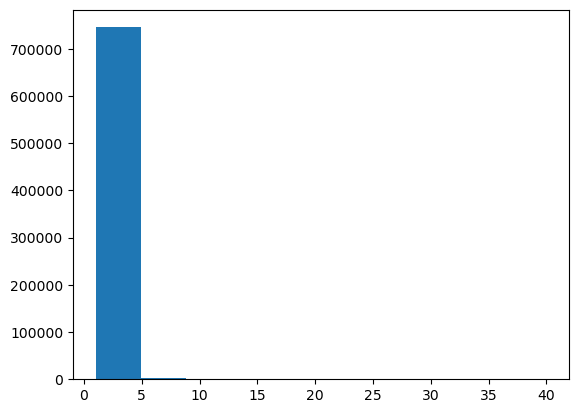

In [34]:
plt.hist(review_df.groupby(by='userId')['rating'].count().values) 
plt.show()

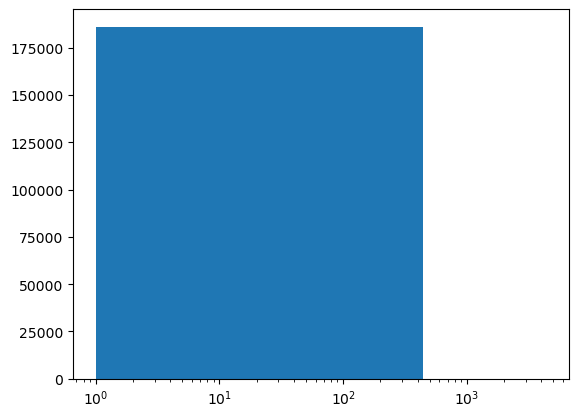

In [36]:
plt.hist(review_df.groupby(by='productId')['rating'].count().values) 
plt.xscale('log')
plt.show()